In [388]:
import sarracen
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize

plt.rcParams.update({"text.usetex": True})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

# set code units
_density = 5.941E-07 # g/cm^3
_mass = 1.989E+33 # g       
_mass_particle = 2.516698E-10
_length = 1.496E+13 # cm    
_time = 5.023E+06 # s
_energy = 1.765E+46 # erg
_velocity = 2.978E+06 # cm/s    
_opacity = 1.125E-07 # cm^2/g
_G = 1.000E+00              
_c = 1.007E+04       
_mu_0 = 1.000E+00
_a = 1.435E-21

# useful constants
cm_to_au = 6.68459e-14
yr_2_s = 365 * 24 * 60 * 60

In [183]:
gammas = [1.01, 1.1, 5/3]

labels = ['1.01', 'isotherm', 'adiabatic']

datasets = {}

for i, value in enumerate(labels):
    sdf, sdf_sinks = sarracen.read_phantom(f'Data/Phantom-Dumps/apep-periastron-{value}_00100')
    datasets[gammas[i]] = [sdf, sdf_sinks]


In [184]:
datasets[1.01][0]

,iorig,iseed_sink,x,y,z,vx,vy,vz,u,Tdust,h,alpha,divv
0,1,1,7.158444,-2.956247,-0.953645,-22.357875,-59.920538,-98.340634,6.919107,10970.406429,0.526667,0.0,235.187531
1,2,1,7.457773,-3.185005,-0.795035,8.509180,-83.510181,-81.984667,6.919107,10970.406429,0.528313,0.0,235.462112
2,3,1,6.880926,-3.088904,-0.733507,-50.975725,-73.600206,-75.639824,6.919107,10970.406429,0.529363,0.0,234.256195
3,4,1,7.444097,-2.783838,-1.060603,7.098946,-42.141564,-109.370256,6.919107,10970.406429,0.524271,0.0,234.276291
4,5,1,7.306478,-3.387858,-0.512408,-7.092468,-104.428564,-52.839969,6.919107,10970.406429,0.531507,0.0,234.622238
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4973196,7825117,1,5.169204,-2.115409,-1.864647,-89.076877,10.666137,-75.446994,6.791780,10768.420042,0.857325,0.0,81.506058
4973197,7825118,1,5.574237,-4.137582,-1.433056,-72.688530,-71.154654,-57.984015,6.791749,10768.370597,0.844459,0.0,80.532089
4973198,7825119,1,6.168260,-2.851306,-2.594172,-48.653303,-19.109575,-104.964856,6.791841,10768.515784,0.849636,0.0,79.793633
4973199,7825120,1,5.056552,-3.040265,-1.608437,-93.634998,-26.755192,-65.080256,6.791768,10768.400329,0.844748,0.0,79.914597


In [185]:
datasets[1.01][0].describe()

,iorig,iseed_sink,x,y,z,vx,vy,vz,u,Tdust,h,alpha,divv
count,4.892255e+06,4.892255e+06,4.892255e+06,4.892255e+06,4.892255e+06,4.892255e+06,4.892255e+06,4.892255e+06,4.892255e+06,4.892255e+06,4.892255e+06,4.892255e+06,4.892255e+06
mean,4.932342e+06,1.762306e+00,5.080580e+02,-9.778537e+01,1.549749e+00,9.332484e+00,-1.580667e+00,3.527087e-02,5.785865e+01,9.173533e+04,1.803935e+01,6.513475e-01,2.048903e-01
std,1.930059e+06,4.256708e-01,7.591356e+02,1.022982e+03,1.079434e+03,2.856428e+01,3.104361e+01,3.455440e+01,2.107567e+02,3.341564e+05,1.749597e+01,4.117340e-01,2.253370e+00
min,1.000000e+00,1.000000e+00,-2.994646e+03,-2.998549e+03,-2.994476e+03,-1.171458e+02,-1.174590e+02,-1.174165e+02,6.261598e-03,9.927842e+00,9.122405e-02,0.000000e+00,-5.286741e+01
25%,3.309034e+06,2.000000e+00,-1.468334e+01,-6.318496e+02,-6.520882e+02,-1.511005e+00,-2.022718e+01,-2.417707e+01,5.965812e+00,9.458840e+03,5.345988e+00,0.000000e+00,2.557960e-02
50%,5.240632e+06,2.000000e+00,5.188277e+02,6.904855e+01,9.174555e-01,1.320780e+01,4.689162e+00,1.789061e-01,6.923751e+00,1.097766e+04,1.225917e+01,8.551160e-01,6.480886e-02
75%,6.602058e+06,2.000000e+00,9.739144e+02,4.722151e+02,6.570751e+02,2.425760e+01,2.089438e+01,2.427460e+01,6.938140e+00,1.100047e+04,2.446503e+01,9.601225e-01,1.532188e-01
max,7.825121e+06,2.000000e+00,2.998688e+03,2.992544e+03,2.997265e+03,1.178032e+02,1.176408e+02,1.174470e+02,6.268916e+03,9.939415e+06,2.284045e+02,1.000000e+00,2.367571e+02


C:\Users\ryanw\AppData\Local\Temp\ipykernel_2796\218618470.py:6: DeprecationWarning: The default rotation point is currently the midpoint of the x/y/z bounds, but will change to [x, y, z] = [0, 0, 0] in Sarracen version 1.3.0.
  ax = datasets[gamma][0].render('rho', ax=axes[i], log_scale=True, xlim=lim, ylim=lim, rotation=[0, 90, 00],
C:\Users\ryanw\AppData\Local\Temp\ipykernel_2796\218618470.py:6: DeprecationWarning: The default rotation point is currently the midpoint of the x/y/z bounds, but will change to [x, y, z] = [0, 0, 0] in Sarracen version 1.3.0.
  ax = datasets[gamma][0].render('rho', ax=axes[i], log_scale=True, xlim=lim, ylim=lim, rotation=[0, 90, 00],
C:\Users\ryanw\AppData\Local\Temp\ipykernel_2796\218618470.py:6: DeprecationWarning: The default rotation point is currently the midpoint of the x/y/z bounds, but will change to [x, y, z] = [0, 0, 0] in Sarracen version 1.3.0.
  ax = datasets[gamma][0].render('rho', ax=axes[i], log_scale=True, xlim=lim, ylim=lim, rotation=[0

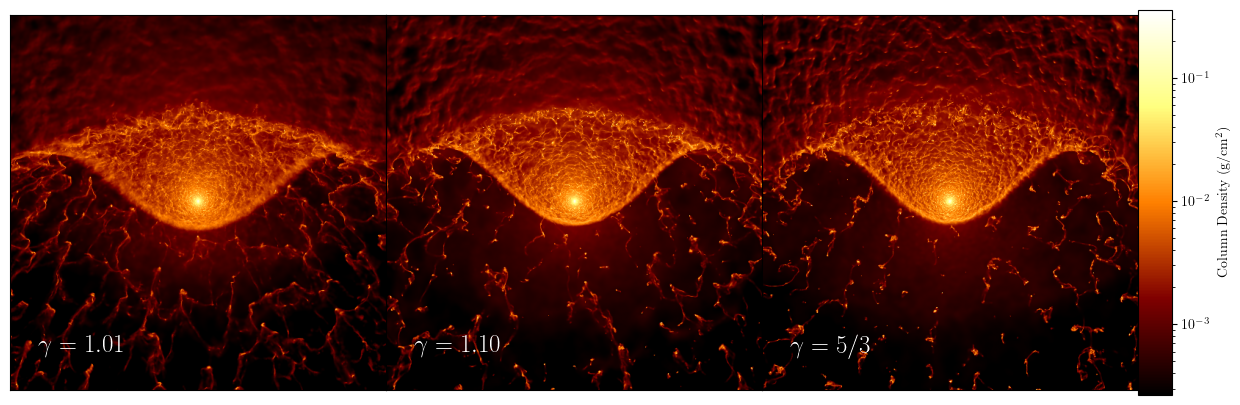

In [436]:
fig, axes = plt.subplots(figsize=(15, 5), ncols=4, gridspec_kw={'wspace':0, 'width_ratios':[0.323, 0.323, 0.323, 0.03]})
lim = (-1000, 1000)
vmin, vmax = 3e-11, 4e-8
cmap = 'afmhot'
for i, gamma in enumerate(gammas):
    ax = datasets[gamma][0].render('rho', ax=axes[i], log_scale=True, xlim=lim, ylim=lim, rotation=[0, 90, 00], 
                                   cbar=False, vmin=vmin, vmax=vmax, cmap=cmap)
    text = rf'$\gamma={gamma:.2f}$' if i < 2 else rf'$\gamma=5/3$'
    axes[i].text(-850, -800, text, c='w', fontdict={'size':18, 'weight':'bold'})

mult = _mass / (_length**2)
cmappable = ScalarMappable(LogNorm(vmin * mult, vmax * mult))
cmappable.set_cmap(cmap)
plt.colorbar(cmappable, cax=axes[3], label=r'Column Density (g/cm$^{2}$)')

fig.savefig('Images/MRes_Plots/Column_Density_Comparison.png', dpi=400, bbox_inches='tight')
fig.savefig('Images/MRes_Plots/Column_Density_Comparison.pdf', dpi=400, bbox_inches='tight')

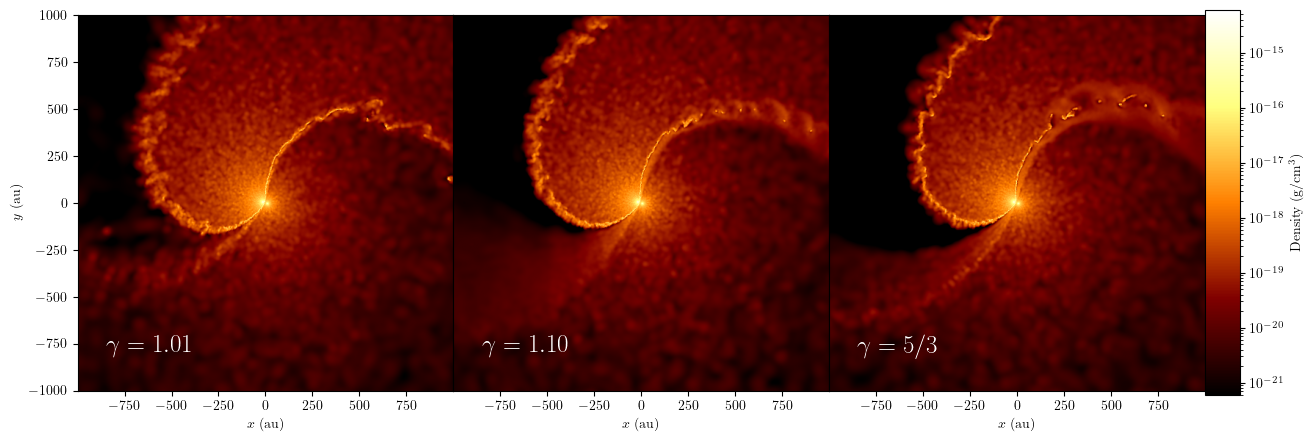

In [439]:
fig, axes = plt.subplots(figsize=(15, 5), ncols=4, gridspec_kw={'wspace':0, 'width_ratios':[0.323, 0.323, 0.323, 0.03]})
lim = (-1000, 1000)
vmin, vmax = 1e-15, 1e-8
cmap = 'afmhot'
# fig, ax = plt.subplots(figsize=(15, 15))

# ax = datasets[1.01][0].render('rho', ax=ax, xsec=0, log_scale=True, xlim=lim, ylim=lim, 
#                                    vmin=vmin, vmax=vmax, cmap=cmap)
for i, gamma in enumerate(gammas):
    ax = datasets[gamma][0].render('rho', ax=axes[i], xsec=0, log_scale=True, xlim=lim, ylim=lim, 
                                   cbar=False, vmin=vmin, vmax=vmax, cmap=cmap)
    text = rf'$\gamma={gamma:.2f}$' if i < 2 else rf'$\gamma=5/3$'
    axes[i].text(-850, -800, text, c='w', fontdict={'size':18, 'weight':'bold'})

mult = _mass / (_length**3)
cmappable = ScalarMappable(LogNorm(vmin * mult, vmax * mult))
cmappable.set_cmap(cmap)
plt.colorbar(cmappable, cax=axes[3], label=r'Density (g/cm$^{3}$)')

for i, ax in enumerate(axes[:3]):
    ax.set_xticks([-750, -500, -250, 0, 250, 500, 750])
    ax.set_xlabel(r'$x$ (au)')
    if i > 0:
        ax.set_yticks([])
        ax.set_ylabel('')
    else:
        ax.set_ylabel(r'$y$ (au)')
    

fig.savefig('Images/MRes_Plots/CrossSec_Density_Comparison.png', dpi=400, bbox_inches='tight')
fig.savefig('Images/MRes_Plots/CrossSec_Density_Comparison.pdf', dpi=400, bbox_inches='tight')

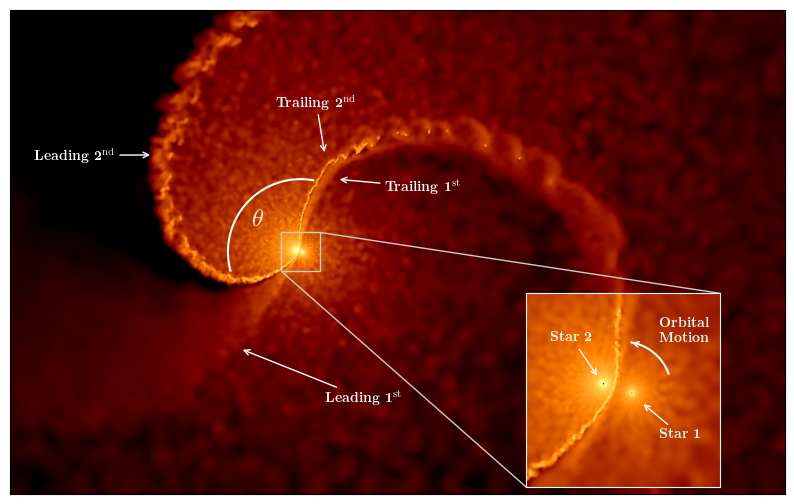

In [188]:


fig, ax = plt.subplots(figsize=(10, 7))
vmin, vmax = 1e-15, 1e-8
cmap = 'afmhot'
ax = datasets[1.1][0].render('rho', ax=ax, xsec=0, log_scale=True, xlim=(-1200, 2000), ylim=(-1000, 1000), 
                                   cbar=False, vmin=vmin, vmax=vmax, cmap=cmap,
                                    x_pixels=1000, y_pixels=700)

radius = 300
theta = np.deg2rad(np.linspace(260, 375, 100)) - np.pi
circ_y = radius * np.sin(theta)
circ_x = radius * np.cos(theta)
ax.plot(circ_x, circ_y, c='w')
ax.text(-200, 110, r"$\mathbf{\theta}$", c='w', size=18)

ax.annotate(r"\textbf{Leading 1$^{\rm st}$}", xytext=(100, -620), xy=(-250, -400), arrowprops={'arrowstyle':"->", 'color':'w'}, c='w')
ax.annotate(r"\textbf{Leading 2$^{\rm nd}$}", xytext=(-1100, 380), xy=(-610, 400), arrowprops={'arrowstyle':"->", 'color':'w'}, c='w')
ax.annotate(r"\textbf{Trailing 2$^{\rm nd}$}", xytext=(-100, 600), xy=(100, 400), arrowprops={'arrowstyle':"->", 'color':'w'}, c='w')
ax.annotate(r"\textbf{Trailing 1$^{\rm st}$}", xytext=(350, 250), xy=(150, 300), arrowprops={'arrowstyle':"->", 'color':'w'}, c='w')

ax2 = inset_axes(ax, width="40%", height="40%", loc=4)
for spine in ax2.spines.values():
    spine.set_edgecolor('w')
mark_inset(ax, ax2, loc1=1, loc2=3, fc="none", ec="0.8")
ax2 = datasets[1.1][0].render('rho', ax=ax2, xsec=0, log_scale=True, xlim=(-80, 80), ylim=(-80, 80), 
                                   cbar=False, vmin=vmin, vmax=100*vmax, cmap=cmap)

inset_r = 40
inset_theta = np.deg2rad(np.linspace(380, 440, 50))
inset_circ_x = inset_r * np.cos(inset_theta)
inset_circ_y = inset_r * np.sin(inset_theta)
ax2.plot(inset_circ_x, inset_circ_y, c='w')
ax2.annotate("", xytext=(10, 38.6), xy=(5, 40), arrowprops={'arrowstyle':"->", 'color':'w'}, c='w')
ax2.text(30, 40, r"\textbf{Orbital}"+"\n"+r"\textbf{Motion}", c='w', fontweight='black')

ax2.annotate(r"\textbf{Star 1}", xytext=(30, -40), xy=(15, -10), arrowprops={'arrowstyle':"->", 'color':'w'}, c='w')
ax2.annotate(r"\textbf{Star 2}", xytext=(-60, 40), xy=(-20, 10), arrowprops={'arrowstyle':"->", 'color':'w'}, c='w')
for _ax in [ax, ax2]:
    _ax.set(xticks=[], yticks=[], xlabel='', ylabel='')

fig.savefig('Images/MRes_Plots/CWB_Structure.png', dpi=400, bbox_inches='tight')
fig.savefig('Images/MRes_Plots/CWB_Structure.pdf', dpi=400, bbox_inches='tight')

In [369]:
# gamma = 1.1
# sdf_new['P'] = (gamma - 1) * sdf_new['rho'] * sdf_new['u']
# sdf_new['r'] = np.sqrt(sdf_new['x']**2 + sdf_new['y']**2 + sdf_new['z']**2)
for i, gamma in enumerate(gammas):
    datasets[gamma][0].calc_density()
    datasets[gamma][0]['P'] = (gamma - 1) * datasets[gamma][0]['rho'] * datasets[gamma][0]['u']
    datasets[gamma][0]['r'] = np.sqrt(datasets[gamma][0]['x']**2 + datasets[gamma][0]['y']**2 + datasets[gamma][0]['z']**2)
    datasets[gamma][0]['v'] = np.sqrt(datasets[gamma][0]['vx']**2 + datasets[gamma][0]['vy']**2 + datasets[gamma][0]['vz']**2) * (_length / 1e5) / _time

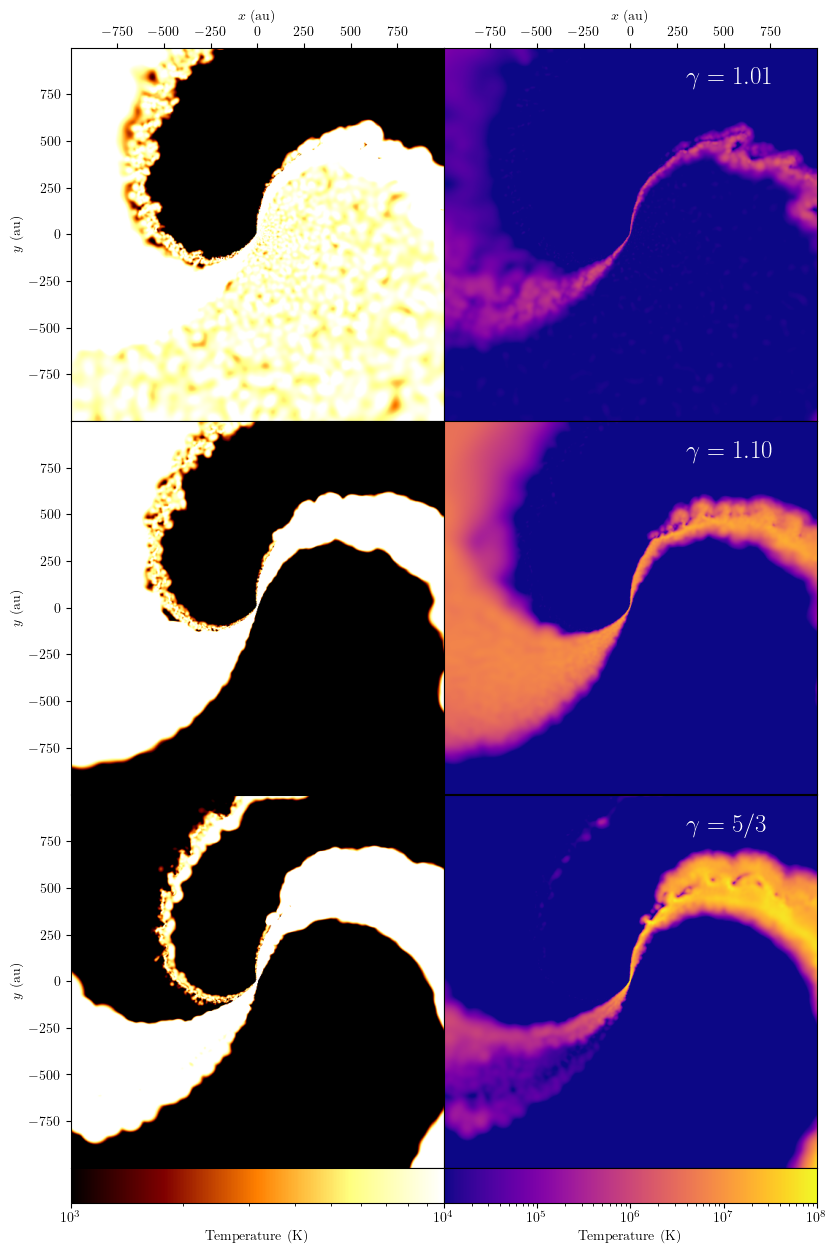

In [273]:
fig, axes = plt.subplots(figsize=(9.63, 15), ncols=2, nrows=4, gridspec_kw={'wspace':0, 'hspace':0, 'height_ratios':[0.323, 0.323, 0.323, 0.03],
                                                                         'width_ratios':[1, 1]})
lim = (-1000, 1000)

vmin = [1e3, 1e+4]
vmax = [1e+4, 1e+8]
cmap = ['afmhot', 'plasma']

for i, gamma in enumerate(gammas):
    for j in range(2):
        ax = datasets[gamma][0].render('Tdust', ax=axes[i, j], xsec=0, log_scale=True, xlim=lim, ylim=lim, 
                                       cbar=False, vmin=vmin[j], vmax=vmax[j], cmap=cmap[j])
        text = rf'$\gamma={gamma:.2f}$' if i < 2 else rf'$\gamma=5/3$'
        if j == 1:
            axes[i, j].text(300, 800, text, c='w', fontdict={'size':18, 'weight':'bold'})

cbar_ticks = [[100, 1e3, 1e4], [1e5, 1e6, 1e7, 1e8]]

for j in range(2):
    cmappable = ScalarMappable(LogNorm(vmin[j], vmax[j]))
    cmappable.set_cmap(cmap[j])
    plt.colorbar(cmappable, cax=axes[3, j], label='Temperature (K)', ticks=cbar_ticks[j],orientation='horizontal', fraction=0.001)

for i in range(3):
    for j in range(2):
        ax = axes[i, j]
        if i == 0:
            ax.set_xticks([-750, -500, -250, 0, 250, 500, 750])
            ax.set_xlabel(r'$x$ (au)')
            ax.xaxis.tick_top()
            ax.xaxis.set_label_position('top')
        else:
            ax.set_xticks([])
            ax.set_xlabel('')
        if j > 0:
            ax.set_yticks([])
            ax.set_ylabel('')
        else:
            ax.set_yticks([-750, -500, -250, 0, 250, 500, 750])
            ax.set_ylabel(r'$y$ (au)')

fig.savefig('Images/MRes_Plots/Temp-Comparison.png', dpi=400, bbox_inches='tight')
fig.savefig('Images/MRes_Plots/Temp-Comparison.pdf', dpi=400, bbox_inches='tight')

In [280]:
# colour_vals = np.log10(sdf_new['Tdust'])
# norm_values = colour_vals - np.min(colour_vals)
# norm_values /= np.max(norm_values)
cmap = 'viridis'
# rgb = mpl.colormaps[cmap](norm_values)

for i, gamma in enumerate(gammas):
    fig, ax = plt.subplots(figsize=(9, 5))
    
    sdf = datasets[gamma][0]
    sort = np.array(np.argsort(sdf['Tdust'])).flatten()

    tmin, tmax = 10, 1e7
    # ax.plot(sdf_new['r'] * _length * cm_to_au, sdf_new['P'] * _density * _energy / _mass, linestyle='', marker=',', markersize=1e-8)
    scatter = ax.scatter(sdf['r'].to_numpy()[sort] * _length * cm_to_au, sdf['P'].to_numpy()[sort] * _density * _energy / _mass, 
                         c=sdf['Tdust'].to_numpy()[sort], cmap=cmap, vmax=tmax, norm='log',
               marker=',', s=1e-2, rasterized=True, alpha=0.2)
    ax.set(xscale='log', yscale='log',
          xlabel='Radius (au)', ylabel=r'Pressure (erg/cm$^3$)',
          xlim=(2, 3e3))
    
    cbar = plt.colorbar(scatter, ax=ax, label=r'Temperature (K)')
    
    cbar.solids.set(alpha=1)
    
    fig.savefig(f'Images/MRes_Plots/P_vs_r_gamma{gamma:.2f}.png', dpi=400, bbox_inches='tight')
    fig.savefig(f'Images/MRes_Plots/P_vs_r_gamma{gamma:.2f}.pdf', dpi=400, bbox_inches='tight')
    plt.close('all')
    print(f'{gamma} done')

ERROR! Session/line number was not unique in database. History logging moved to new session 600
1.01 done
1.1 done
1.6666666666666667 done


In [398]:
shock_cuts = {}
for gamma in gammas:
    print(gamma)
    sdf = datasets[gamma][0]
    print(len(sdf))
    temp_cut = sdf[(sdf['Tdust'] < 1.5e4) & (sdf['Tdust'] > 1e3)]
    print(len(temp_cut))
    r_cut = temp_cut[temp_cut['r'] * _length * cm_to_au > 30]
    print(len(r_cut))
    r_P_cut = r_cut[np.log10(r_cut['P'] * _density * _energy / _mass) > (-2.6266 * np.log10(r_cut['r'] * _length * cm_to_au) - 3.12019)]
    print(len(r_P_cut))
    
    print(_mass_particle * len(r_P_cut) * 0.01) # total mass
    print(_mass_particle * len(r_P_cut) * 0.01 / (((3000 / cm_to_au) / (1020 * 1e5)) / yr_2_s)) # total mass per year

    shock_cuts[gamma] = r_P_cut

1.01
4892255
3086891
3064996
3064996
7.713669303208e-06
5.528678233757142e-07
1.1
4995347
2915304
2899634
2899634
7.297503088532e-06
5.230396183767337e-07
1.6666666666666667
5036585
2975573
2959245
2959245
7.4475259730100004e-06
5.33792325335976e-07


[None]

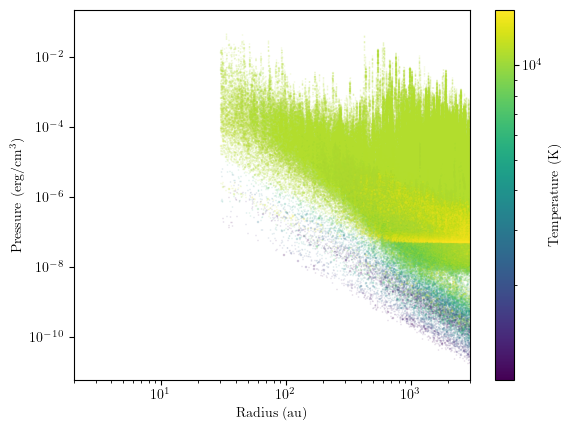

In [402]:
sort = np.array(np.argsort(r_P_cut['Tdust'])).flatten()[::-1]
gamma = 1.1
fig, ax = plt.subplots()
cmap='viridis'

sort = np.array(np.argsort(shock_cuts[gamma]['Tdust'])).flatten()

# ax.plot(sdf_new['r'] * _length * cm_to_au, sdf_new['P'] * _density * _energy / _mass, linestyle='', marker=',', markersize=1e-8)
scatter = ax.scatter(shock_cuts[gamma]['r'].to_numpy()[sort] * _length * cm_to_au, shock_cuts[gamma]['P'].to_numpy()[sort] * _density * _energy / _mass, 
                     c=shock_cuts[gamma]['Tdust'].to_numpy()[sort], cmap=cmap, norm='log',
           marker=',', s=1e-2, rasterized=True, alpha=0.2)
ax.set(xscale='log', yscale='log',
      xlabel='Radius (au)', ylabel=r'Pressure (erg/cm$^3$)',
      xlim=(30, 3e3))

cbar = plt.colorbar(scatter, ax=ax, label=r'Temperature (K)')

cbar.solids.set(alpha=1)

C:\Users\ryanw\AppData\Local\Temp\ipykernel_2796\2694597738.py:11: DeprecationWarning: The default rotation point is currently the midpoint of the x/y/z bounds, but will change to [x, y, z] = [0, 0, 0] in Sarracen version 1.3.0.
  ax = shock_cuts[gamma].render('rho', ax=ax, log_scale=True, xlim=xlim, ylim=ylim, rotation=[280, 10, 23.8],


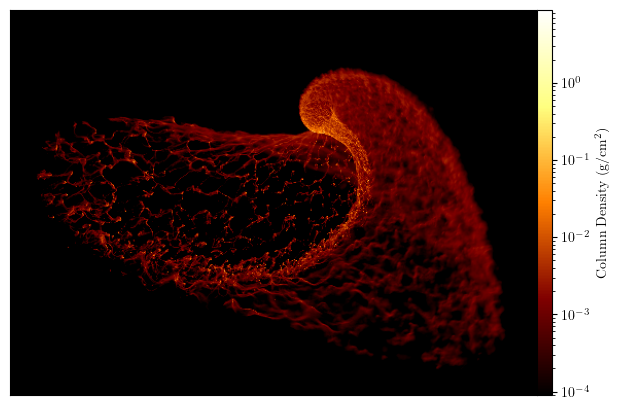

In [435]:
# fig, axes = plt.subplots(figsize=(15, 5), ncols=4, gridspec_kw={'wspace':0, 'width_ratios':[0.323, 0.323, 0.323, 0.03]})
fig, ax = plt.subplots(figsize=(8, 6))
xlim = (-2600, 3000)
ylim = (-3300, 800)
vmin, vmax = 1e-11, 1e-6
cmap = 'afmhot'

gamma = 1.1
# fig, ax = plt.subplots(figsize=(15, 15))

ax = shock_cuts[gamma].render('rho', ax=ax, log_scale=True, xlim=xlim, ylim=ylim, rotation=[280, 10, 23.8],
                           cbar=False, vmin=vmin, vmax=vmax, cmap=cmap)

mult = _mass / (_length**2)
cmappable = ScalarMappable(LogNorm(vmin * mult, vmax * mult))
cmappable.set_cmap(cmap)
plt.colorbar(cmappable, ax=ax, label=r'Column Density (g/cm$^{2}$)', aspect=25, shrink=0.835, pad=0)

# for i, ax in enumerate(axes[:3]):
#     ax.set_xticks([-2000, -1000, 0, 1000, 2000])
#     ax.set_xlabel(r'$x$ (au)')
#     if i > 0:
#         ax.set_yticks([])
#         ax.set_ylabel('')
#     else:
#         ax.set_ylabel(r'$y$ (au)')

fig.savefig('Images/MRes_Plots/Apep-Hydro-phi-1.02.png', dpi=400, bbox_inches='tight')
fig.savefig('Images/MRes_Plots/Apep-Hydro-phi-1.02.pdf', dpi=400, bbox_inches='tight')

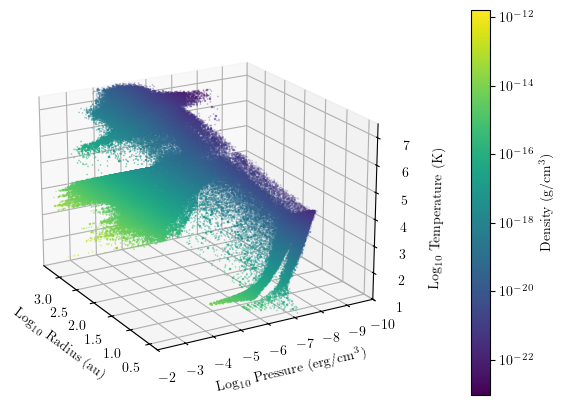

In [444]:
cmap = 'viridis'
gamma = 1.10
sdf = datasets[gamma][0]
sort = np.array(np.argsort(sdf['rho'])).flatten()
sort = sort[::2] # cut down size by 2

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(np.log10(sdf['r'].to_numpy()[sort] * _length * cm_to_au), np.log10(sdf['P'].to_numpy()[sort] * _density * _energy / _mass), 
                         np.log10(sdf['Tdust'].to_numpy()[sort]), c=sdf['rho'].to_numpy()[sort] * _mass / _length**3, cmap=cmap, norm='log',
               marker=',', s=1e-2, rasterized=True)
elev, azim, roll = 20, 150, None
ax.view_init(elev=elev, azim=azim)
cbar = plt.colorbar(scatter, ax=ax, label=r'Density (g/cm$^{3}$)', pad=0.15)
ax.set(xlabel=r'Log$_{10}$ Radius (au)', ylabel=r'Log$_{10}$ Pressure (erg/cm$^3$)', zlabel=r'Log$_{10}$ Temperature (K)',
      xlim=(np.log10(2), np.log10(3e3)), ylim=(-10, -2), zlim=(1, 7.5))

fig.savefig(f'Images/MRes_Plots/P_vs_r_vs_T_gamma{gamma:.2f}.png', dpi=400, bbox_inches='tight')
fig.savefig(f'Images/MRes_Plots/P_vs_r_vs_T_gamma{gamma:.2f}.pdf', dpi=400, bbox_inches='tight')

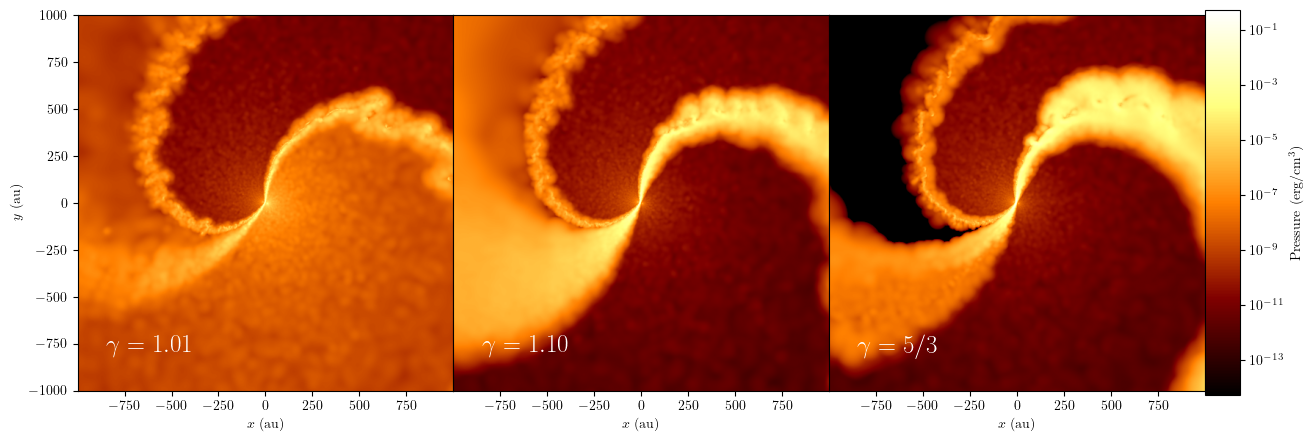

In [364]:
fig, axes = plt.subplots(figsize=(15, 5), ncols=4, gridspec_kw={'wspace':0, 'width_ratios':[0.323, 0.323, 0.323, 0.03]})
lim = (-1000, 1000)
vmin, vmax = 1e-21, 1e-7
cmap = 'afmhot'
# fig, ax = plt.subplots(figsize=(15, 15))

# ax = datasets[1.01][0].render('rho', ax=ax, xsec=0, log_scale=True, xlim=lim, ylim=lim, 
#                                    vmin=vmin, vmax=vmax, cmap=cmap)
for i, gamma in enumerate(gammas):
    ax = datasets[gamma][0].render('P', ax=axes[i], xsec=0, log_scale=True, xlim=lim, ylim=lim, 
                                   cbar=False, vmin=vmin, vmax=vmax, cmap=cmap)
    text = rf'$\gamma={gamma:.2f}$' if i < 2 else rf'$\gamma=5/3$'
    axes[i].text(-850, -800, text, c='w', fontdict={'size':18, 'weight':'bold'})
    
cmappable = ScalarMappable(LogNorm(vmin * _density * _energy / _mass, vmax * _density * _energy / _mass))
cmappable.set_cmap(cmap)
plt.colorbar(cmappable, cax=axes[3], label=r'Pressure (erg/cm$^3$)')

for i, ax in enumerate(axes[:3]):
    ax.set_xticks([-750, -500, -250, 0, 250, 500, 750])
    ax.set_xlabel(r'$x$ (au)')
    if i > 0:
        ax.set_yticks([])
        ax.set_ylabel('')
    else:
        ax.set_ylabel(r'$y$ (au)')
    

fig.savefig('Images/MRes_Plots/CrossSec_Pressure_Comparison.png', dpi=400, bbox_inches='tight')
fig.savefig('Images/MRes_Plots/CrossSec_Pressure_Comparison.pdf', dpi=400, bbox_inches='tight')

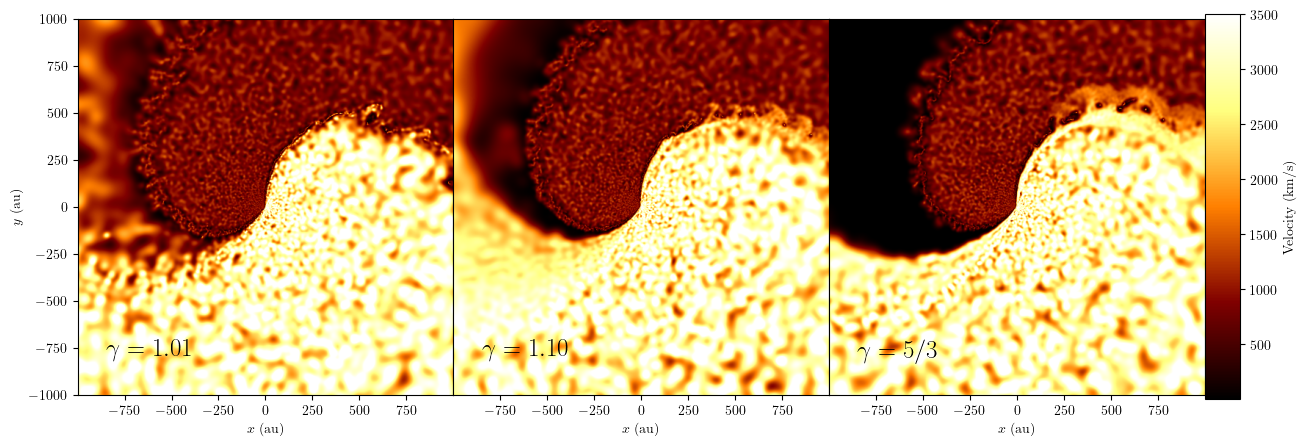

In [378]:
fig, axes = plt.subplots(figsize=(15, 5), ncols=4, gridspec_kw={'wspace':0, 'width_ratios':[0.323, 0.323, 0.323, 0.03]})
lim = (-1000, 1000)
vmin, vmax = 1e0, 3.5e3
cmap = 'afmhot'
# fig, ax = plt.subplots(figsize=(15, 15))

# ax = datasets[1.01][0].render('rho', ax=ax, xsec=0, log_scale=True, xlim=lim, ylim=lim, 
#                                    vmin=vmin, vmax=vmax, cmap=cmap)
for i, gamma in enumerate(gammas):
    ax = datasets[gamma][0].render('v', ax=axes[i], xsec=0, log_scale=False, xlim=lim, ylim=lim, 
                                   cbar=False, vmin=vmin, vmax=vmax, cmap=cmap)
    text = rf'$\gamma={gamma:.2f}$' if i < 2 else rf'$\gamma=5/3$'
    axes[i].text(-850, -800, text, c='k', fontdict={'size':18, 'weight':'bold'})
    
cmappable = ScalarMappable(Normalize(vmin, vmax))
cmappable.set_cmap(cmap)
plt.colorbar(cmappable, cax=axes[3], label=r'Velocity (km/s)')

for i, ax in enumerate(axes[:3]):
    ax.set_xticks([-750, -500, -250, 0, 250, 500, 750])
    ax.set_xlabel(r'$x$ (au)')
    if i > 0:
        ax.set_yticks([])
        ax.set_ylabel('')
    else:
        ax.set_ylabel(r'$y$ (au)')
    

fig.savefig('Images/MRes_Plots/CrossSec_Velocity_Comparison.png', dpi=400, bbox_inches='tight')
fig.savefig('Images/MRes_Plots/CrossSec_Velocity_Comparison.pdf', dpi=400, bbox_inches='tight')

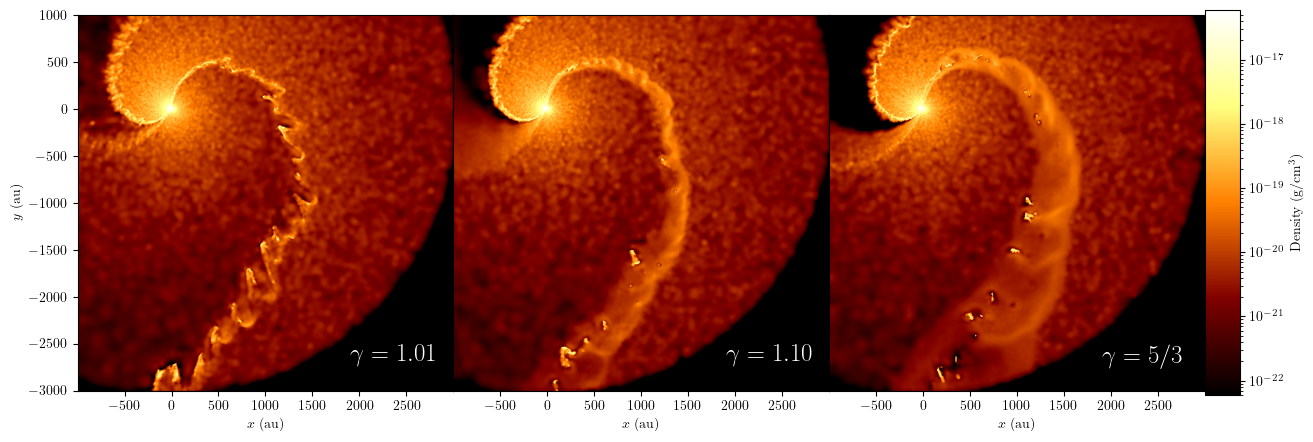

In [442]:
fig, axes = plt.subplots(figsize=(15, 5), ncols=4, gridspec_kw={'wspace':0, 'width_ratios':[0.323, 0.323, 0.323, 0.03]})
xlim = (-1000, 3000)
ylim = (-3000, 1000)
vmin, vmax = 1e-16, 1e-10
cmap = 'afmhot'
# fig, ax = plt.subplots(figsize=(15, 15))

for i, gamma in enumerate(gammas):
    ax = datasets[gamma][0].render('rho', ax=axes[i], xsec=0, log_scale=True, xlim=xlim, ylim=ylim, 
                               cbar=False, vmin=vmin, vmax=vmax, cmap=cmap)
    text = rf'$\gamma={gamma:.2f}$' if i < 2 else rf'$\gamma=5/3$'
    axes[i].text(1900, -2700, text, c='w', fontdict={'size':18, 'weight':'bold'})
    
mult = _mass / (_length**3)
cmappable = ScalarMappable(LogNorm(vmin * mult, vmax * mult))
cmappable.set_cmap(cmap)
plt.colorbar(cmappable, cax=axes[3], label=r'Density (g/cm$^{3}$)')

for i, ax in enumerate(axes[:3]):
    ax.set_xticks([-500, 0, 500, 1000, 1500, 2000, 2500])
    ax.set_xlabel(r'$x$ (au)')
    if i > 0:
        ax.set_yticks([])
        ax.set_ylabel('')
    else:
        ax.set_ylabel(r'$y$ (au)')

fig.savefig('Images/MRes_Plots/CrossSec_Density_Comparison-large.png', dpi=400, bbox_inches='tight')
fig.savefig('Images/MRes_Plots/CrossSec_Density_Comparison-large.pdf', dpi=400, bbox_inches='tight')